# Ejercicio de programación Regresión Polinomial

In [1]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np

ruta = "/content/gdrive/MyDrive/parkinsons_updrs.data"

data = pd.read_csv(ruta)

print("Dimensión del dataset:", data.shape)
print(data.head())

Dimensión del dataset: (5875, 22)
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.6470       28.905       35.810    0.00528   
4         1   72    0    33.6420       29.187       36.375    0.00335   

   Jitter(Abs)  Jitter:RAP  Jitter:PPQ5  ...  Shimmer(dB)  Shimmer:APQ3  \
0     0.000034     0.00401      0.00317  ...        0.230       0.01438   
1     0.000017     0.00132      0.00150  ...        0.179       0.00994   
2     0.000025     0.00205      0.00208  ...        0.181       0.00734   
3     0.000027     0.00191      0.00264  ...        0.327       0.01106   
4     0.000020     0.00093      0.00130  ...        0.176       0.00679   

   Shimmer:APQ5  Shimmer:APQ11  Shimmer:DDA       NHR     HNR     RPDE  \
0 

In [3]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2 Regresión polinomica

Se implementa la regresion polinomial para predecir el la capacidad adquisitiva de una persona. El archivo `Datasets/capacidad_adquisitiva.csv` contiene un dataset para entrenamiento de capacidad adquisitiva de las personas considerando la edad de las personas de la ciudad de Sucre. La primera columna es la edad y la segunda columna es la capacidad adquisitiva en bolivianos por mes.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [4]:
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'capacidad_adquisitiva.csv'), delimiter=';')
# Preparar características y variable objetivo

X = data.drop(columns=["subject#", "motor_UPDRS", "total_UPDRS"]).to_numpy(dtype=float)
y = data["total_UPDRS"].to_numpy(dtype=float)

m = y.size
n = X.shape[1]

print("Cantidad de registros m:", m)
print("Cantidad de características n:", n)
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

Cantidad de registros m: 5875
Cantidad de características n: 19
Dimensión de X: (5875, 19)
Dimensión de y: (5875,)


La desviación estándar es una forma de medir cuánta variación hay en el rango de valores de una característica en particular (la mayoría de los puntos caeran en un rango de ± 2 en relación a la desviaciones estándar de la media); esta es una alternativa a tomar el rango de valores (max-min). En `numpy`, se puede usar la función `std` para calcular la desviacion estandar.

Por ejemplo, la caracteristica`X[:, 0]` contiene todos los valores de $x_1$ (edades) en el conjunto de entrenamiento, entonces `np.std(X[:, 0])` calcula la desviacion estandar de las edades.
En el momento en que se llama a la función `featureNormalize`, la columna adicional de unos correspondiente a $ x_0 = 1 $ aún no se ha agregado a $ X $.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normalize una caracteristica, es importante almacenar los valores usados para la normalización - el valor de la media y el valor de la desviación estandar usado para los calculos. Despues de aprender los parametros del modelo, se deseara predecir la capacidad adquisitiva que no se han visto antes. Dado un nuevo valor de x (edad), primero se debe normalizar x usando la media y la desviacion estandar que se empleo anteriormente en el conjunto de entrenamiento para entrenar el modelo.
</div>
<a id="featureNormalize"></a>

In [22]:
# Conservamos las 19 características para la regresión multivariable
X_multi = X.copy()

# Característica utilizada para la regresión polinómica
X_poly = data[["motor_UPDRS"]].to_numpy(dtype=float)

In [16]:
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'ro', ms=2, mec='k')
    pyplot.ylabel('total_UPDRS')
    pyplot.xlabel('motor_UPDRS')


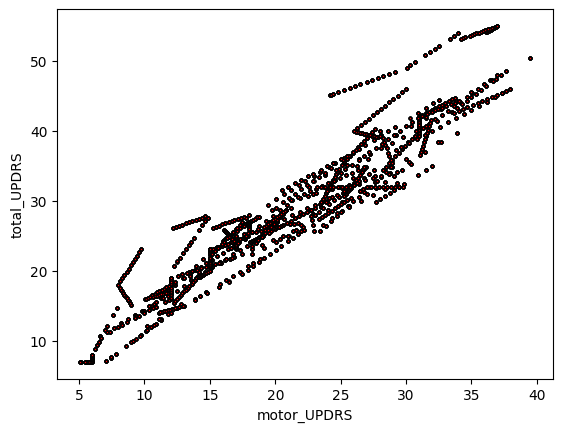

In [17]:
plotData(X_poly, y)

In [23]:
X_poly = np.concatenate([X_poly, X_poly * X_poly], axis=1)
print(X_poly.shape)

(5875, 2)


In [11]:
print(X_poly)

[[  72. 5184.]
 [  72. 5184.]
 [  72. 5184.]
 ...
 [  61. 3721.]
 [  61. 3721.]
 [  61. 3721.]]


In [18]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [24]:
# llama featureNormalize con los datos cargados
# Normalizar las características polinómicas
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)

print("Media:", mu_poly)
print("Desviación estándar:", sigma_poly)
print("Dimensión:", X_poly_norm.shape)

Media: [ 21.29622854 519.60331978]
Desviación estándar: [  8.12858964 357.694501  ]
Dimensión: (5875, 2)


In [20]:
print(X_poly_norm)

[[ 0.84919669]
 [ 0.87970629]
 [ 0.91021589]
 ...
 [ 0.02445338]
 [-0.03558164]
 [-0.09635479]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [25]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
# Agregar término de intersección
X_poly_gd = np.concatenate([np.ones((m, 1)), X_poly_norm],axis=1)

print("Dimensión X polinómica:", X_poly_gd.shape)

Dimensión X polinómica: (5875, 3)


In [26]:
print(X_poly_gd)

[[ 1.          0.84919669  0.77043477]
 [ 1.          0.87970629  0.80970909]
 [ 1.          0.91021589  0.8493273 ]
 ...
 [ 1.          0.02445338 -0.16094263]
 [ 1.         -0.03558164 -0.2189278 ]
 [ 1.         -0.09635479 -0.2762697 ]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [28]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [29]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


Theta polinómico: [29.01540918  5.62913093  4.5319998 ]
Costo inicial: 475.1587935858037
Costo final: 6.016559579834854


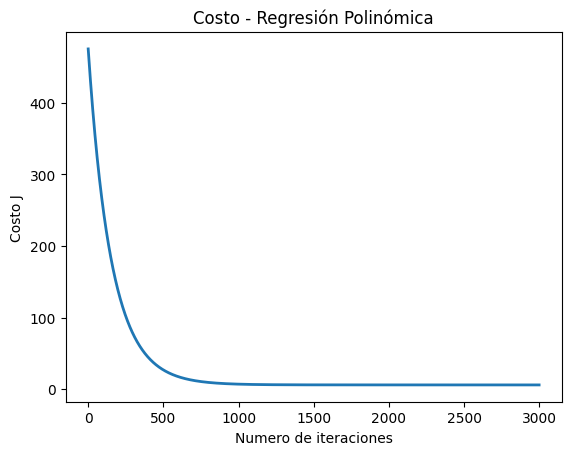

In [30]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha_poly = 0.003
num_iters_poly = 3000

# inicializa theta y ejecuta el descenso por el gradiente
theta_poly = np.zeros(X_poly_gd.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_poly_gd, y, theta_poly, alpha_poly, num_iters_poly)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title("Costo - Regresión Polinómica")

print("Theta polinómico:", theta_poly)
print("Costo inicial:", J_history_poly[0])
print("Costo final:", J_history_poly[-1])

# print('La capacidad adquisitiva para una persona de 33 (usando el descenso por el gradiente): ${:.0f}'.format(price))

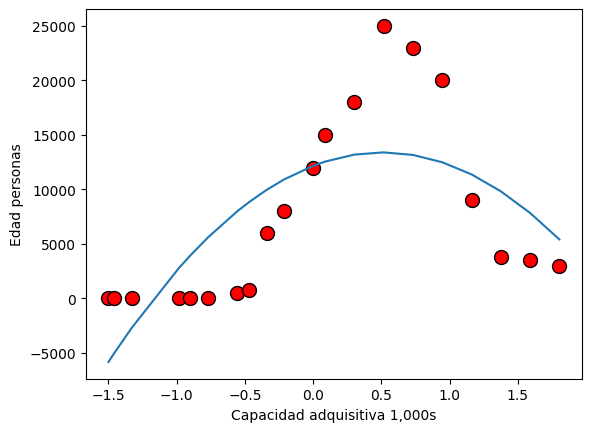

In [ ]:
# plotData(X[:, 1], y)
# pyplot.plot(X[:, 1], np.dot(X, theta), '-')

In [ ]:
# X_array = [1, 23, 529]
# X_array[1:3] = (X_array[1:3] - mu) / sigma

In [ ]:
#X_array[1:3]
#print(np.dot(X_array, theta))

7076.418790199557


In [31]:
# REGRESIÓN LINEAL MULTIVARIABLE

# Normalizar las 19 características
X_multi_norm, mu_multi, sigma_multi = featureNormalize(X_multi)

# Agregar término de intersección
X_multi_gd = np.concatenate(
    [np.ones((m, 1)), X_multi_norm],
    axis=1
)

print("Dimensión X multivariable:", X_multi_gd.shape)

Dimensión X multivariable: (5875, 20)


Costo inicial: 452.5313203836605
Costo final: 47.16390799988128
Theta multivariable: [29.01894228  2.6682472  -1.28821032  0.88006385  0.22025311 -2.27699057
  1.22413633 -1.02899279  1.23274317  1.03091326 -0.64539367 -0.97856393
 -0.84039476  1.30118414 -0.97789203 -0.83139495 -2.67482341  0.43230544
 -2.20600569  1.54731782]


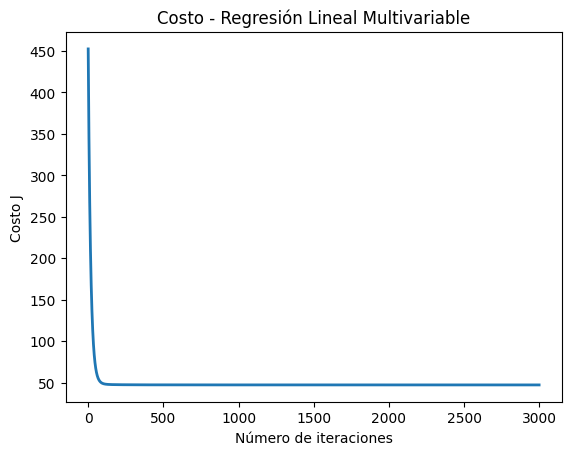

In [32]:
# Entrenamiento de regresión lineal multivariable

alpha_multi = 0.03
num_iters_multi = 3000

theta_multi = np.zeros(X_multi_gd.shape[1])

theta_multi, J_history_multi = gradientDescentMulti(
    X_multi_gd,
    y,
    theta_multi,
    alpha_multi,
    num_iters_multi
)

# Gráfica de costo
pyplot.plot(np.arange(len(J_history_multi)), J_history_multi, lw=2)
pyplot.xlabel("Número de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Costo - Regresión Lineal Multivariable")

print("Costo inicial:", J_history_multi[0])
print("Costo final:", J_history_multi[-1])
print("Theta multivariable:", theta_multi)

<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [33]:
# Cargar datos
# Datos para la ecuación normal
X_normal = X_multi.copy()
y_normal = y.copy()

m_normal = y_normal.size

# Agregar término de intersección
X_normal = np.concatenate(
    [np.ones((m_normal, 1)), X_normal],
    axis=1
)

print("Dimensión X_normal:", X_normal.shape)
print("Dimensión y_normal:", y_normal.shape)

Dimensión X_normal: (5875, 20)
Dimensión y_normal: (5875,)


In [34]:
def normalEqn(X, y):
    theta = np.dot(
          np.dot(
              np.linalg.pinv(np.dot(X.T, X)),
              X.T
          ),
          y
      )
    return theta

In [35]:
# Calcula los parametros con la ecuación de la normal
theta_normal = normalEqn(X_normal, y_normal);

costo_normal = computeCostMulti(X_normal, y_normal, theta_normal)

print("Theta ecuación normal:", theta_normal)
print("Costo ecuación normal:", costo_normal)

Theta ecuación normal: [ 3.97647726e+01  3.02997100e-01 -2.79710236e+00  1.65806657e-02
  4.35548643e+01 -6.40726765e+04  1.11803266e+02 -3.35183290e+02
  2.42030003e+02  1.49256624e+02 -8.86485227e+00 -1.16182378e+02
 -6.37819307e+01  5.36850174e+01 -3.40111569e+01 -1.52127974e+01
 -6.28405226e-01  3.99337287e+00 -3.14567560e+01  1.75068810e+01]
Costo ecuación normal: 47.14008936812409


In [36]:
# Realizar 100 predicciones con los tres modelos

cantidad = 100

# -------------------------
# MODELO POLINÓMICO
# -------------------------
motor_100 = data[["motor_UPDRS"]].iloc[:cantidad].to_numpy(dtype=float)

motor_100_poly = np.concatenate(
    [motor_100, motor_100 ** 2],
    axis=1
)

motor_100_norm = (motor_100_poly - mu_poly) / sigma_poly

motor_100_gd = np.concatenate(
    [np.ones((cantidad, 1)), motor_100_norm],
    axis=1
)

pred_poly = np.dot(motor_100_gd, theta_poly)


# -------------------------
# MODELO MULTIVARIABLE
# -------------------------
X_100 = X_multi[:cantidad]

X_100_norm = (X_100 - mu_multi) / sigma_multi

X_100_gd = np.concatenate(
    [np.ones((cantidad, 1)), X_100_norm],
    axis=1
)

pred_multi = np.dot(X_100_gd, theta_multi)


# -------------------------
# ECUACIÓN NORMAL
# -------------------------
X_100_normal = np.concatenate(
    [np.ones((cantidad, 1)), X_100],
    axis=1
)

pred_normal = np.dot(X_100_normal, theta_normal)

# Valores reales
reales = y[:cantidad]

In [37]:
resultados = pd.DataFrame({
    "Real": reales,
    "Polinómica": pred_poly,
    "Multivariable": pred_multi,
    "Ecuación Normal": pred_normal
})

print(resultados)

      Real  Polinómica  Multivariable  Ecuación Normal
0   34.398   37.287259      34.093216        34.212862
1   34.894   37.636993      29.475447        29.546235
2   35.389   37.988285      34.726657        34.720258
3   35.810   38.286969      34.013825        33.437030
4   36.375   38.689816      32.241153        32.244391
..     ...         ...            ...              ...
95  46.013   48.251602      35.522912        35.440401
96  46.635   48.996382      33.735690        33.873191
97  47.257   49.748281      33.857738        33.860298
98  47.970   50.616455      37.804868        37.522905
99  34.399   37.287259      31.395903        31.501575

[100 rows x 4 columns]


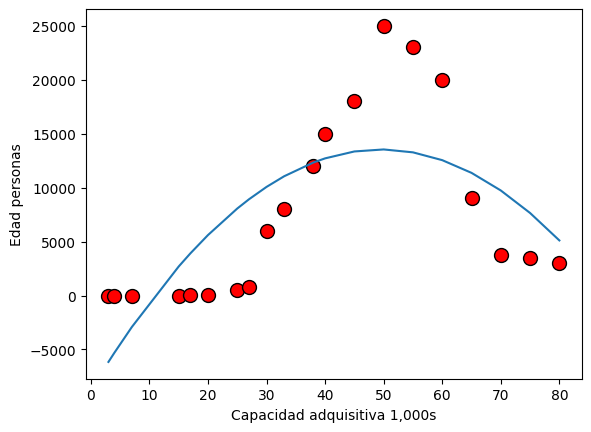

In [ ]:
#plotData(X[:, 1], y)
#X = np.concatenate([np.ones((m, 1)), X], axis=1)
#X = np.concatenate([X, X * X], axis=1)

#pyplot.plot(X[:, 1], np.dot(X, theta), '-')

In [38]:
# Evaluación de las 100 predicciones

mae_poly = np.mean(np.abs(reales - pred_poly))
mae_multi = np.mean(np.abs(reales - pred_multi))
mae_normal = np.mean(np.abs(reales - pred_normal))

rmse_poly = np.sqrt(np.mean((reales - pred_poly) ** 2))
rmse_multi = np.sqrt(np.mean((reales - pred_multi) ** 2))
rmse_normal = np.sqrt(np.mean((reales - pred_normal) ** 2))

print("REGRESIÓN POLINÓMICA")
print("MAE:", mae_poly)
print("RMSE:", rmse_poly)

print("\nREGRESIÓN LINEAL MULTIVARIABLE")
print("MAE:", mae_multi)
print("RMSE:", rmse_multi)

print("\nECUACIÓN NORMAL")
print("MAE:", mae_normal)
print("RMSE:", rmse_normal)

REGRESIÓN POLINÓMICA
MAE: 2.0301910799747014
RMSE: 2.0796977955271614

REGRESIÓN LINEAL MULTIVARIABLE
MAE: 7.217725167085413
RMSE: 8.231150124041717

ECUACIÓN NORMAL
MAE: 7.200102935216888
RMSE: 8.199378338892947


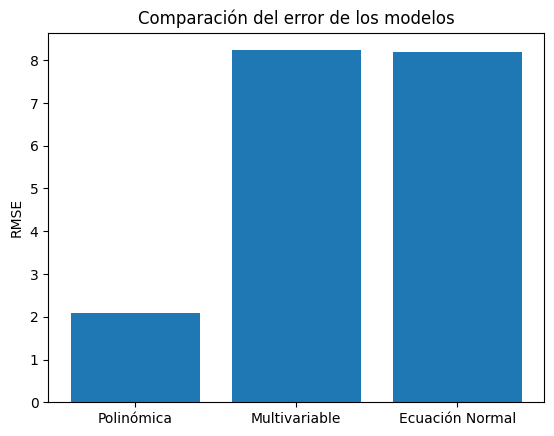

In [39]:
modelos = ["Polinómica", "Multivariable", "Ecuación Normal"]
errores = [rmse_poly, rmse_multi, rmse_normal]

pyplot.bar(modelos, errores)
pyplot.ylabel("RMSE")
pyplot.title("Comparación del error de los modelos")
pyplot.show()